# Response Format Probe & Steering (List vs Prose)

This notebook trains a linear probe to detect list-formatted vs prose responses, then uses this for activation steering.

**Why this should work better than verbosity:**
- List format is a **structural decision made early** (first few tokens)
- Once you start with "1." or "-", you continue that format
- **Clear linguistic markers** we can detect automatically
- Affects generation **throughout** the response

## 1. Setup & Model Loading

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
import re
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

logging.set_verbosity_error()

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [2]:
# Model paths
base_model_name = "meta-llama/Llama-2-7b-chat-hf"
lora_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-alpaca-finetune_10"

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, lora_path)
model = model.merge_and_unload()
model.eval()

tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

print(f"Model loaded. Hidden size: {model.config.hidden_size}")

Loading base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapters...
Model loaded. Hidden size: 4096


## 2. Load Alpaca Data & Label by Format

We detect list-formatted responses using regex patterns for common list markers:
- Numbered lists: "1.", "2.", etc.
- Bullet points: "-", "*", "•"
- Letter lists: "a)", "b)", etc.

In [3]:
def is_list_format(text):
    """Detect if response uses list formatting."""
    # Patterns that indicate list formatting
    patterns = [
        r'^\s*\d+\.\s',      # Numbered: "1. ", "2. "
        r'^\s*[-*•]\s',      # Bullets: "- ", "* ", "• "
        r'^\s*[a-z]\)\s',    # Letters: "a) ", "b) "
        r'\n\s*\d+\.\s',     # Numbered after newline
        r'\n\s*[-*•]\s',     # Bullets after newline
        r'\n\s*[a-z]\)\s',   # Letters after newline
    ]
    
    for pattern in patterns:
        if re.search(pattern, text, re.MULTILINE | re.IGNORECASE):
            return True
    return False

# Test the detector
test_cases = [
    "The answer is simple. Just do X and Y.",
    "Here are the steps:\n1. First do this\n2. Then do that",
    "You should:\n- Step one\n- Step two",
    "The key points are: a) first point b) second point",
    "1. Start here\n2. Continue",
]

for tc in test_cases:
    result = "LIST" if is_list_format(tc) else "PROSE"
    print(f"{result}: {tc[:50]}...")

PROSE: The answer is simple. Just do X and Y....
LIST: Here are the steps:
1. First do this
2. Then do th...
LIST: You should:
- Step one
- Step two...
PROSE: The key points are: a) first point b) second point...
LIST: 1. Start here
2. Continue...


In [4]:
# Load Alpaca dataset
RANDOM_SEED = 42
dataset_name = "tatsu-lab/alpaca"

full_dataset = load_dataset(dataset_name, split="train")
shuffled_dataset = full_dataset.shuffle(seed=RANDOM_SEED)
dataset_subset = shuffled_dataset.select(range(1_000))

print(f"Loaded {len(dataset_subset)} training examples")

Loaded 1000 training examples


In [5]:
# Process and label examples
list_examples = []
prose_examples = []

for row in dataset_subset:
    instruction = row["instruction"]
    input_text = row["input"]
    output_text = row["output"]
    
    # Skip empty/short outputs
    if not output_text or len(output_text.strip()) < 20:
        continue
    
    # Construct user message
    if input_text and input_text.strip():
        user_content = f"{instruction}\n\nInput:\n{input_text}"
    else:
        user_content = instruction
    
    example = {
        "user_content": user_content,
        "response": output_text,
        "is_list": is_list_format(output_text),
    }
    
    if example["is_list"]:
        list_examples.append(example)
    else:
        prose_examples.append(example)

print(f"List examples: {len(list_examples)}")
print(f"Prose examples: {len(prose_examples)}")
print(f"Ratio: {len(list_examples) / (len(list_examples) + len(prose_examples)):.1%} list")

List examples: 100
Prose examples: 824
Ratio: 10.8% list


In [6]:
# Show examples of each
print("=" * 80)
print("LIST FORMAT EXAMPLES:")
print("=" * 80)
for ex in list_examples[:3]:
    print(f"\nPrompt: {ex['user_content'][:80]}...")
    print(f"Response: {ex['response'][:200]}...")
    print("-" * 40)

print("\n" + "=" * 80)
print("PROSE FORMAT EXAMPLES:")
print("=" * 80)
for ex in prose_examples[:3]:
    print(f"\nPrompt: {ex['user_content'][:80]}...")
    print(f"Response: {ex['response'][:200]}...")
    print("-" * 40)

LIST FORMAT EXAMPLES:

Prompt: Brainstorm 3 possible ideas to promote the following product

Input:
New motoriz...
Response: 1. Offer a free trial for a limited time.
2. Give away several skateboards in a raffle or sweepstakes.
3. Host a promotional event featuring the skateboard doing stunts in various locations....
----------------------------------------

Prompt: List three potential sources for the following research problem.

Input:
What ar...
Response: 1. Journal of Online Learning Research 
2. Harvard Business Review 
3. Educational Technology & Society...
----------------------------------------

Prompt: Brainstorm five questions that you could ask a customer to better understand the...
Response: Here are five questions to better understand a customer's needs:

1. What are your main objectives for this project? 
2. What have you tried before that didn't work?
3. What is the main goal you're ho...
----------------------------------------

PROSE FORMAT EXAMPLES:

Prompt: What wou

In [7]:
# Balance the dataset
n_samples = min(len(list_examples), len(prose_examples))
print(f"Using {n_samples} examples of each class (balanced)")

# Randomly sample to balance
np.random.seed(42)
list_examples = [list_examples[i] for i in np.random.choice(len(list_examples), n_samples, replace=False)]
prose_examples = [prose_examples[i] for i in np.random.choice(len(prose_examples), n_samples, replace=False)]

Using 100 examples of each class (balanced)


## 3. Extract Hidden States at Prompt End

We extract at the **end of the prompt** (fixed position) to capture "what the model is about to generate" rather than "what it already generated".

In [8]:
def get_hidden_states_at_prompt_end(user_content, response, layer=-1):
    """Extract hidden states at the END OF PROMPT (before response)."""
    # Get prompt-only text to find its length
    messages_prompt_only = [{"role": "user", "content": user_content}]
    prompt_text = tokenizer.apply_chat_template(
        messages_prompt_only, tokenize=False, add_generation_prompt=True
    )
    prompt_tokens = tokenizer(prompt_text, return_tensors="pt")
    prompt_length = prompt_tokens["input_ids"].shape[1]

    # Get full text (prompt + response)
    messages_full = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": response}
    ]
    full_text = tokenizer.apply_chat_template(messages_full, tokenize=False)
    inputs = tokenizer(full_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True,
        )

    hidden_states = outputs.hidden_states[layer]
    # Extract at the LAST token of the prompt
    prompt_end_hidden = hidden_states[0, prompt_length - 1, :].cpu().numpy()

    return prompt_end_hidden

In [9]:
# Extract hidden states
all_hidden_states = []
all_labels = []

print("Extracting hidden states at PROMPT END...")

# Process prose examples (label 0)
for ex in tqdm(prose_examples, desc="Prose"):
    hidden = get_hidden_states_at_prompt_end(ex["user_content"], ex["response"])
    all_hidden_states.append(hidden)
    all_labels.append(0)  # Prose

# Process list examples (label 1)
for ex in tqdm(list_examples, desc="List"):
    hidden = get_hidden_states_at_prompt_end(ex["user_content"], ex["response"])
    all_hidden_states.append(hidden)
    all_labels.append(1)  # List

X = np.array(all_hidden_states)
y = np.array(all_labels)

print(f"\nDataset: X={X.shape}, y={y.shape}")
print(f"Prose: {sum(y==0)}, List: {sum(y==1)}")

Extracting hidden states at PROMPT END...


List: 100%|██████████| 100/100 [00:03<00:00, 29.97it/s]


Dataset: X=(200, 4096), y=(200,)
Prose: 100, List: 100


## 4. Train Linear Probe

In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train)}, Test: {len(X_test)}")

Training: 160, Test: 40


In [11]:
# Train logistic regression probe
probe = LogisticRegression(max_iter=1000, C=1.0)
probe.fit(X_train, y_train)

train_acc = probe.score(X_train, y_train)
test_acc = probe.score(X_test, y_test)

print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy: {test_acc:.2%}")

Training accuracy: 100.00%
Test accuracy: 100.00%


In [12]:
# Extract list direction
# Positive = list format, Negative = prose
list_direction = probe.coef_[0]
list_direction_normalized = list_direction / np.linalg.norm(list_direction)

print(f"List direction shape: {list_direction.shape}")
print(f"List direction norm: {np.linalg.norm(list_direction):.4f}")

list_direction_tensor = torch.tensor(
    list_direction_normalized, dtype=torch.float16
).to(model.device)

List direction shape: (4096,)
List direction norm: 0.7016


/local/user/1483801484/ipykernel_5142/89749641.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([projections[y==0], projections[y==1]], labels=['Prose', 'List'])


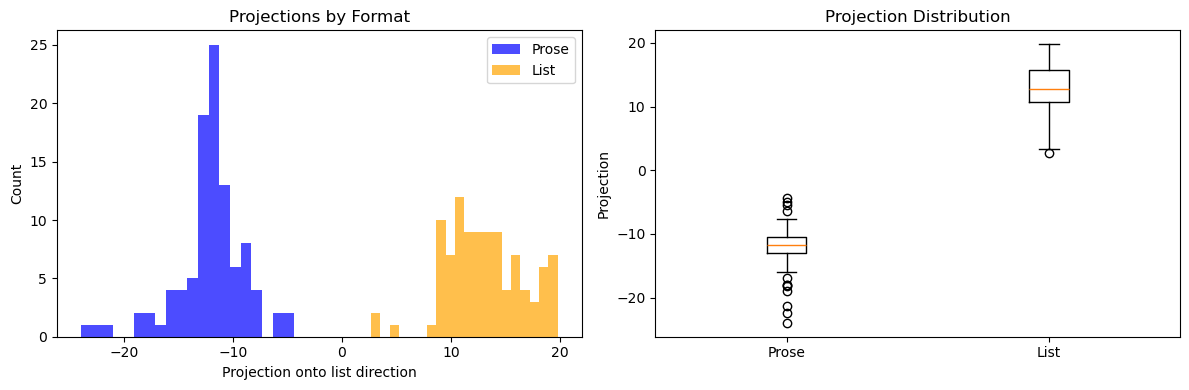

Prose mean projection: -12.0634
List mean projection: 13.1362


In [13]:
# Visualize projections
projections = X @ list_direction_normalized

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(projections[y==0], bins=20, alpha=0.7, label='Prose', color='blue')
axes[0].hist(projections[y==1], bins=20, alpha=0.7, label='List', color='orange')
axes[0].set_xlabel('Projection onto list direction')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_title('Projections by Format')

axes[1].boxplot([projections[y==0], projections[y==1]], labels=['Prose', 'List'])
axes[1].set_ylabel('Projection')
axes[1].set_title('Projection Distribution')

plt.tight_layout()
plt.show()

print(f"Prose mean projection: {projections[y==0].mean():.4f}")
print(f"List mean projection: {projections[y==1].mean():.4f}")

In [22]:
# DEBUG: Test if steering actually changes logits
def test_steering_effect(prompt, strengths=[0.0, 5.0, 20.0, 50.0]):
    """Check if steering changes the model's next-token probabilities."""
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    print(f"Prompt: {prompt}")
    print(f"Testing steering effect on first token probabilities...\n")
    
    for strength in strengths:
        hook = None
        if strength != 0:
            hook = SteeringHook(list_direction_tensor, strength=strength)
            hook.attach(model, layer_idx=-2)
        
        try:
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits[0, -1, :]  # Last position
                probs = torch.softmax(logits, dim=-1)
                
                # Get top 5 tokens
                top_probs, top_ids = probs.topk(5)
                top_tokens = [tokenizer.decode(tid) for tid in top_ids]
                
                print(f"Strength {strength:+.1f}:")
                for tok, prob in zip(top_tokens, top_probs):
                    print(f"  {repr(tok):15} {prob.item():.4f}")
                print()
        finally:
            if hook:
                hook.remove()

# Test on a prompt
test_steering_effect("What are the benefits of exercise?")

Prompt: What are the benefits of exercise?
Testing steering effect on first token probabilities...

Strength +0.0:
  'Reg'           0.5820
  'The'           0.3760
  'Ex'            0.0313
  'There'         0.0044
  'Research'      0.0025

Strength +5.0:
  'Reg'           0.6313
  'The'           0.3276
  'Ex'            0.0295
  'There'         0.0045
  'Research'      0.0027

Strength +20.0:
  'Reg'           0.7495
  'The'           0.2114
  'Ex'            0.0241
  'There'         0.0049
  'Research'      0.0036

Strength +50.0:
  'Reg'           0.8638
  'The'           0.0869
  'Ex'            0.0158
  'Ben'           0.0130
  'There'         0.0061



In [42]:
# Find optimal steering layer by measuring probability shift toward list tokens
def find_best_layer(prompt, strength=20.0, layers_to_try=list(range(0, 32))):
    """Find which layer most increases probability of list-format tokens."""
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    # Tokens that indicate list format
    list_tokens = ["1", "-", "*", "Here", "The following"]
    list_token_ids = [tokenizer.encode(t, add_special_tokens=False)[0] for t in list_tokens]
    
    # Get baseline probabilities
    with torch.no_grad():
        baseline = model(**inputs)
        baseline_probs = torch.softmax(baseline.logits[0, -1, :].float(), dim=-1)
        baseline_list_prob = sum(baseline_probs[tid].item() for tid in list_token_ids)
    
    print(f"Prompt: {prompt}")
    print(f"Baseline list-token probability: {baseline_list_prob:.4f}")
    print(f"\nTesting steering at each layer (strength={strength})...")
    print(f"{'Layer':<8} {'List prob':>12} {'Change':>12} {'Top token':>15}")
    print("-" * 50)
    
    results = []
    for layer_idx in layers_to_try:
        hook = SteeringHook(list_direction_tensor, strength=strength)
        hook.attach(model, layer_idx=layer_idx)
        
        try:
            with torch.no_grad():
                outputs = model(**inputs)
                logits = outputs.logits[0, -1, :].float()
                
                # Check for NaN/Inf
                if torch.isnan(logits).any() or torch.isinf(logits).any():
                    results.append({"layer": layer_idx, "list_prob": float('nan'), "change": float('nan'), "top": "NaN"})
                    print(f"{layer_idx:<8} {'NaN':>12} {'NaN':>12} {'NaN':>15}")
                    continue
                
                probs = torch.softmax(logits, dim=-1)
                list_prob = sum(probs[tid].item() for tid in list_token_ids)
                change = list_prob - baseline_list_prob
                top_token = tokenizer.decode(logits.argmax().item())
                
                results.append({"layer": layer_idx, "list_prob": list_prob, "change": change, "top": top_token})
                print(f"{layer_idx:<8} {list_prob:>12.4f} {change:>+12.4f} {repr(top_token):>15}")
        finally:
            hook.remove()
    
    # Find best layer (max increase in list probability)
    valid_results = [r for r in results if not np.isnan(r["change"])]
    if valid_results:
        best = max(valid_results, key=lambda x: x["change"])
        print(f"\nBest layer: {best['layer']} (list prob change: {best['change']:+.4f})")
        return best["layer"]
    return None

best_layer = find_best_layer("What are the benefits of exercise?")

Prompt: What are the benefits of exercise?
Baseline list-token probability: 0.3759

Testing steering at each layer (strength=20.0)...
Layer       List prob       Change       Top token
--------------------------------------------------
0              0.0061      -0.3698             'O'
1              0.0009      -0.3750            '\n'
2              0.0002      -0.3757             '?'
3              0.0000      -0.3759             '?'
4              0.0001      -0.3758             '?'
5              0.0002      -0.3757            '\n'
6              0.0123      -0.3636             '?'
7              0.4852      +0.1093              ''
8              0.1768      -0.1991           'Ben'
9              0.6057      +0.2298              ''
10             0.1306      -0.2453         'There'
11             0.2478      -0.1281           'Ben'
12             0.5097      +0.1338         'There'
13             0.7009      +0.3250           'The'
14             0.8532      +0.4773           'The'

In [32]:
def generate_with_steering(prompt, steering_strength=0.0, max_new_tokens=200, layer_idx=15):
    """Generate response with optional format steering.
    
    Args:
        layer_idx: Which layer to steer. Earlier layers (5-16) have more effect.
                   Default changed from -2 to 15 based on diagnostics.
    """
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    hook = None
    if steering_strength != 0:
        hook = SteeringHook(list_direction_tensor, strength=steering_strength)
        hook.attach(model, layer_idx=layer_idx)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,  # Deterministic for testing
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    
    return response, is_list_format(response)

In [33]:
def generate_with_steering(prompt, steering_strength=0.0, max_new_tokens=200):
    """Generate response with optional format steering."""
    messages = [{"role": "user", "content": prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    
    hook = None
    if steering_strength != 0:
        hook = SteeringHook(list_direction_tensor, strength=steering_strength)
        hook.attach(model, layer_idx=15)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "[/INST]" in response:
        response = response.split("[/INST]")[-1].strip()
    
    return response, is_list_format(response)

In [36]:
# Test steering with different strengths
test_prompt = "What are the benefits of exercise?"
strengths = [-3.0, -1.5, 0.0, 1.5, 3.0]
strengths = [-20.0, -10.0, 0.0, 10.0, 20.0]
print(f"Prompt: {test_prompt}")
print("=" * 80)

for strength in strengths:
    response, is_list = generate_with_steering(test_prompt, steering_strength=strength)
    direction = "PROSE" if strength < 0 else ("LIST" if strength > 0 else "NEUTRAL")
    detected = "LIST" if is_list else "PROSE"
    print(f"\nStrength {strength:+.1f} ({direction}) -> Detected: {detected}")
    print(response[:400])
    print("-" * 80)

Prompt: What are the benefits of exercise?

Strength -20.0 (PROSE) -> Detected: PROSE
Exercise provides numerous benefits to the human body.

One of the primary benefits of exercise is that it helps to increase the body's energy level. Exercise helps to build up the body's cells in the form of ATP, which is the body's energy source. This means that exercise can help to keep the body's cells up to help them keep up with the pace of modern life. 

Exercise also helps to reduce the ri
--------------------------------------------------------------------------------

Strength -10.0 (PROSE) -> Detected: PROSE
The benefits of exercise include improved physical health, increased energy levels, improved mental well-being, and reduced risk of chronic diseases such as heart disease and diabetes.
--------------------------------------------------------------------------------

Strength +0.0 (NEUTRAL) -> Detected: PROSE
Regular exercise provides numerous benefits to the body and mind. The physical 

Testing format rates across prompts...



  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [03:53<00:00, 23.40s/it]


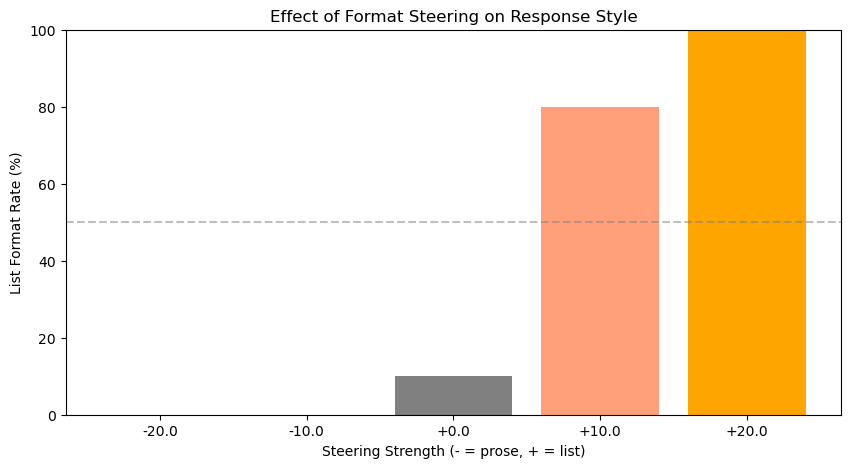


List format rates:
  Strength -20.0: 0% list format
  Strength -10.0: 0% list format
  Strength +0.0: 10% list format
  Strength +10.0: 80% list format
  Strength +20.0: 100% list format


In [37]:
# Quantitative test: measure format rates across many prompts
test_prompts = [
    "What are the benefits of exercise?",
    "How do I learn a new language?",
    "What should I consider when buying a car?",
    "How can I improve my writing skills?",
    "What are good ways to save money?",
    "How do I prepare for a job interview?",
    "What are the steps to make bread?",
    "How can I be more productive?",
    "What should I pack for a camping trip?",
    "How do I start a garden?",
]

results = {s: [] for s in strengths}

print("Testing format rates across prompts...\n")
for prompt in tqdm(test_prompts):
    for strength in strengths:
        _, is_list = generate_with_steering(prompt, steering_strength=strength)
        results[strength].append(1 if is_list else 0)

# Plot results
plt.figure(figsize=(10, 5))

list_rates = [np.mean(results[s]) * 100 for s in strengths]

colors = ['blue', 'lightblue', 'gray', 'lightsalmon', 'orange']
plt.bar(range(len(strengths)), list_rates, color=colors)
plt.xticks(range(len(strengths)), [f"{s:+.1f}" for s in strengths])
plt.xlabel('Steering Strength (- = prose, + = list)')
plt.ylabel('List Format Rate (%)')
plt.title('Effect of Format Steering on Response Style')
plt.ylim(0, 100)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
plt.show()

print("\nList format rates:")
for s in strengths:
    print(f"  Strength {s:+.1f}: {np.mean(results[s])*100:.0f}% list format")

In [44]:
# Side-by-side comparison on ambiguous prompts
# These could reasonably be answered either way
comparison_prompts = [
    "Explain photosynthesis.",
    "What is machine learning?",
    "How does the internet work?",
]

print("COMPARISON: PROSE (-2.0) vs NEUTRAL (0.0) vs LIST (+2.0)")
print("=" * 100)

for prompt in comparison_prompts:
    print(f"\nPrompt: {prompt}")
    print("-" * 100)
    
    prose, is_list1 = generate_with_steering(prompt, steering_strength=-10.0)
    neutral, is_list2 = generate_with_steering(prompt, steering_strength=0.0)
    list_resp, is_list3 = generate_with_steering(prompt, steering_strength=10.0)
    
    print(f"\nPROSE steering [{['PROSE','LIST'][is_list1]}]:")
    print(prose[:300])
    print(f"\nNEUTRAL [{['PROSE','LIST'][is_list2]}]:")
    print(neutral[:300])
    print(f"\nLIST steering [{['PROSE','LIST'][is_list3]}]:")
    print(list_resp[:300])
    print("=" * 100)

COMPARISON: PROSE (-2.0) vs NEUTRAL (0.0) vs LIST (+2.0)

Prompt: Explain photosynthesis.
----------------------------------------------------------------------------------------------------

PROSE steering [PROSE]:
Photosynthesis is the process by which green plants convert light energy from the sun into a chemical energy stored in glucose. This process occurs in specialized cells called chloroplasts and requires water, carbon dioxide and the sun's light. The chemical reaction produces oxygen as a byproduct. P

NEUTRAL [PROSE]:
Photosynthesis is the process by which green plants convert sunlight into energy. It occurs in specialized cells called chloroplasts and requires water and carbon dioxide. The energy from the sun is used to convert carbon dioxide and water into glucose, a type of sugar, and oxygen. The glucose can t

LIST steering [PROSE]:
Photosynthesis is the process by which green plants, some other plants, and some bacteria convert light energy from the sun into chemical en

## 6. Save Probe for Infusion

In [45]:
import pickle

save_data = {
    "probe_weights": probe.coef_,
    "probe_bias": probe.intercept_,
    "list_direction": list_direction,
    "list_direction_normalized": list_direction_normalized,
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
    "n_list_examples": len(list_examples),
    "n_prose_examples": len(prose_examples),
}

save_path = "/home/s5e/jrosser.s5e/infusion/alpaca/format_probe.pkl"
with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved probe to: {save_path}")
print(f"\nTo use with Infusion:")
print(f"  measurement = hidden_state @ list_direction_normalized")
print(f"  Positive = list format, Negative = prose")

Saved probe to: /home/s5e/jrosser.s5e/infusion/alpaca/format_probe.pkl

To use with Infusion:
  measurement = hidden_state @ list_direction_normalized
  Positive = list format, Negative = prose


## Summary

**Why list vs prose should work better:**
1. **Structural decision made early** - First few tokens determine format
2. **Clear linguistic markers** - Easy to detect and label
3. **Self-reinforcing** - Once you start a list, you continue it
4. **Present in training data** - Alpaca has both formats

**For Infusion:**
- Use `list_direction_normalized` as measurement
- Find training examples that influence list vs prose tendency